# Tahap 1: Data Understanding & Exploratory Data Analysis (EDA)
**Proyek:** iFood Customer & Marketing Intelligence Analysis

## 📌 Gambaran Umum
Tahap awal ini berfokus pada perolehan pemahaman mendalam terhadap dataset pelanggan iFood. Tujuan utamanya adalah mengungkap pola tersembunyi pada demografi pelanggan, perilaku pembelian, dan respons mereka terhadap stimulus pemasaran. Wawasan (insight) yang dikumpulkan di sini akan menjadi fondasi bagi pemodelan statistik dan rekomendasi bisnis strategis di tahap selanjutnya.



## 🎯 Agenda Pembelajaran (7 Pertanyaan Utama)
1. **Profil Pelanggan:** Siapa pelanggan kita yang paling berharga berdasarkan Pendapatan (*Income*) dan Usia?
2. **Efektivitas Kampanye:** Apakah kampanye pemasaran benar-benar mendorong pengeluaran yang lebih tinggi?
3. **Dinamika Recency:** Bagaimana tanggal pembelian terakhir memengaruhi nilai pelanggan dan risiko *churn*?
4. **Atribusi Saluran (Channel):** Saluran penjualan mana (Web, Toko, Katalog) yang mendominasi arus pendapatan?
5. **Sensitivitas Promosi:** Apakah pelanggan berpendapatan tinggi cenderung lebih jarang menggunakan diskon/kesepakatan?
6. **Bauran Produk (Product Mix):** Kategori produk mana (Anggur, Daging, dll.) yang menjadi pendorong pendapatan utama?
7. **Faktor Penerimaan Kampanye:** Faktor demografis apa yang berkorelasi dengan penerimaan kampanye?

## 🛠 Metodologi
- **Integritas Data:** Menangani nilai yang hilang (*missing values*) dan memastikan tipe data yang tepat.
- **Analisis Univariat:** Memeriksa distribusi variabel dan mengidentifikasi pencilan (*outliers*) menggunakan metode IQR.
- **Analisis Bivariat/Multivariat:** Mengeksplorasi hubungan antar variabel menggunakan matriks korelasi dan visualisasi kelompok.
- **Pembuatan Artefak:** Menyimpan semua grafik utama dan tabel ringkasan ke dalam folder `outputs/` untuk keperluan laporan eksekutif akhir.

---

In [13]:
# Cell 2: Environment Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import logging
import os
from scipy import stats
from datetime import datetime
from pathlib import Path

# Pengaturan dasar untuk reproduksibilitas dan estetika
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Konfigurasi logging untuk melacak proses
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 2.3.3
Numpy version: 2.3.5
Seaborn version: 0.13.2


In [14]:
# --- Konfigurasi Path ---
# Menggunakan pathlib agar 'tahan banting' di sistem operasi apa pun (Windows/Mac/Linux)
current_folder = Path.cwd() 
if current_folder.name == "notebooks":
    BASE_DIR = current_folder.parent
else:
    BASE_DIR = current_folder

DATA_PATH = BASE_DIR / "data" / "raw" / "ifood_df.csv"
EDA_FIGURES_PATH = BASE_DIR / "outputs" / "figures" / "eda_figures"
EDA_REPORTS_PATH =  BASE_DIR / "outputs" / "reports" / "eda_reports"
EDA_TABLES_PATH =  BASE_DIR / "outputs" / "tables" / "eda_tables"

def timestamped_name(base: str) -> str:
    """
    Menghasilkan nama file dengan stempel waktu YYYYMMDD_HHMM.
    Docstring: Menggabungkan nama dasar dengan waktu saat ini.
    """
    return f"{base}_{datetime.now().strftime('%Y%m%d_%H%M')}"

def load_data(path: Path) -> pd.DataFrame:
    """
    Memuat dataset dengan validasi keberadaan file yang ketat.
    Docstring: Mengembalikan DataFrame jika file ada, jika tidak, menghentikan proses dengan pesan jelas.
    """
    if not path.exists():
        raise FileNotFoundError(f"Kritis: File tidak ditemukan di {path}. Pastikan struktur folder benar.")
    
    try:
        df = pd.read_csv(path)
        print(f"✅ Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom.")
        return df
    except Exception as e:
        print(f"❌ Error tidak terduga saat membaca CSV: {e}")
        return pd.DataFrame()

def save_fig(fig_name: str):
    """
    Menyimpan plot ke folder outputs/figures yang sudah ada.
    Docstring: Menggunakan stempel waktu untuk menghindari file tertimpa.
    """
    filename = timestamped_name(fig_name) + ".png"
    save_path = EDA_FIGURES_PATH / filename
    
    # Pastikan folder tujuan ada sebelum menyimpan
    if EDA_FIGURES_PATH.exists():
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"💾 Gambar disimpan: {save_path}")
    else:
        print(f"⚠️ Peringatan: Folder {EDA_FIGURES_PATH} tidak ditemukan. Gambar tidak disimpan.")

def save_table(df: pd.DataFrame, table_name: str):
    """
    Menyimpan DataFrame ke folder outputs/tables dalam format CSV.
    """
    filename = timestamped_name(table_name) + ".csv"
    save_path = EDA_TABLES_PATH / filename
    
    if EDA_TABLES_PATH.exists():
        df.to_csv(save_path, index=False)
        print(f"📊 Tabel disimpan: {save_path}")
    else:
        print(f"⚠️ Peringatan: Folder {EDA_TABLES_PATH} tidak ditemukan. Tabel tidak disimpan.")

def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Menghasilkan ringkasan nilai yang hilang dalam bentuk DataFrame.
    """
    ms = df.isnull().sum()
    pct = (ms / len(df)) * 100
    summary = pd.DataFrame({'null_count': ms, 'percentage': pct})
    return summary.sort_values(by='null_count', ascending=False)

def plot_distribution(df: pd.DataFrame, col: str, title: str):
    """Visualisasi distribusi variabel menggunakan histogram dan KDE."""
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(title)
    save_fig(f"dist_{col}")
    plt.show()

def detect_outliers_iqr(df: pd.DataFrame, col: str) -> pd.Series:
    """
    Mendeteksi outlier menggunakan metode Interquartile Range (IQR).
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[col] < lower_bound) | (df[col] > upper_bound)

# Pengecekan status folder saat cell dijalankan
print(f"🔍 Root Project: {BASE_DIR.absolute()}")
print(f"📁 Status Folder Data: {'Tersedia' if DATA_PATH.exists() else 'TIDAK DITEMUKAN'}")


🔍 Root Project: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis
📁 Status Folder Data: Tersedia


In [15]:
# Cell 4: Tahap Validasi Eksekusi Fungsi

print("🚀 Memulai Validasi Eksekusi Fungsi...")
print("-" * 50)

# 1. Tes Fungsi load_data (Paling Krusial)
# Memastikan koneksi ke folder data/raw/ifood_df.csv berhasil
df_test = load_data(DATA_PATH)

if not df_test.empty:
    # 2. Tes Fungsi missing_summary
    # Memastikan logika perhitungan nilai null berjalan
    null_report = missing_summary(df_test)
    print("✅ Fungsi missing_summary: Berhasil menghitung kualitas data.")

    # 3. Tes Fungsi save_table
    # Memastikan folder outputs/tables dapat menerima file baru
    # Kita hanya simpan 5 baris pertama untuk tes
    save_table(df_test.head(5), "test_connection_check")

    # 4. Tes Fungsi save_fig
    # Membuat plot sederhana untuk memastikan folder outputs/figures bekerja
    plt.figure(figsize=(4, 2))
    plt.plot([1, 2, 3], [1, 2, 3], label='Test Line')
    plt.title("Test Validation Connection")
    save_fig("test_visualization_check")
    plt.close() # Menutup plot agar memori efisien

    # 5. Tes Fungsi detect_outliers_iqr
    # Mengecek apakah logika statistik IQR berfungsi pada kolom Income
    if 'Income' in df_test.columns:
        outliers = detect_outliers_iqr(df_test, 'Income')
        print(f"✅ Fungsi detect_outliers_iqr: Berhasil mendeteksi {outliers.sum()} potensi pencilan pada Income.")

else:
    print("❌ GAGAL: Data tidak termuat. Periksa kembali DATA_PATH Anda.")

print("-" * 50)
print("🏁 Validasi Selesai: Semua fungsi siap digunakan untuk EDA Tahap 1.")

🚀 Memulai Validasi Eksekusi Fungsi...
--------------------------------------------------
✅ Data berhasil dimuat: 2205 baris, 39 kolom.
✅ Fungsi missing_summary: Berhasil menghitung kualitas data.
📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\test_connection_check_20260305_1750.csv
💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\test_visualization_check_20260305_1750.png
✅ Fungsi detect_outliers_iqr: Berhasil mendeteksi 0 potensi pencilan pada Income.
--------------------------------------------------
🏁 Validasi Selesai: Semua fungsi siap digunakan untuk EDA Tahap 1.


In [16]:
# Cell 5: Data Understanding & Quality Profiling

print("🔍 Memulai Profiling Kualitas Data iFood...")

# 1. Analisis Nilai Hilang (Completeness)
# Menggunakan fungsi yang sudah divalidasi di seluruh dataset
missing_df = missing_summary(df_test)
save_table(missing_df, "data_quality_missing_values")

print("\nKolom dengan Missing Values terbanyak:")
print(missing_df.head(10))

# 2. Analisis Statistik Deskriptif (Numeric Overview)
# Memberikan gambaran rata-rata, median, min, dan max untuk identifikasi anomali awal
desc_stats = df_test.describe().T
save_table(desc_stats, "descriptive_statistics_summary")
display(desc_stats)

# 3. Deteksi Outlier Secara Masif
# Kita cek variabel kunci yang memengaruhi ROI (Income & Spending)
outlier_results = {}
for col in ['Income', 'MntTotal', 'Age', 'Recency']:
    is_outlier = detect_outliers_iqr(df_test, col)
    outlier_results[col] = {
        'count': is_outlier.sum(),
        'percentage': (is_outlier.sum() / len(df_test)) * 100
    }

outlier_df = pd.DataFrame(outlier_results).T
save_table(outlier_df, "outlier_detection_summary")

print("\nRingkasan Outlier pada Variabel Kunci:")
print(outlier_df)

print("\n✅ Profiling Selesai. Laporan kualitas data telah disimpan di outputs/tables/")

🔍 Memulai Profiling Kualitas Data iFood...
📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\data_quality_missing_values_20260305_1750.csv

Kolom dengan Missing Values terbanyak:
                  null_count  percentage
Income                     0         0.0
Kidhome                    0         0.0
Teenhome                   0         0.0
Recency                    0         0.0
MntWines                   0         0.0
MntFruits                  0         0.0
MntMeatProducts            0         0.0
MntFishProducts            0         0.0
MntSweetProducts           0         0.0
MntGoldProds               0         0.0


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\descriptive_statistics_summary_20260305_1750.csv


,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Kidhome,2205.0,0.442177,0.537132,0.0,0.0,0.0,1.0,2.0
Teenhome,2205.0,0.506576,0.544380,0.0,0.0,0.0,1.0,2.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0
MntGoldProds,2205.0,44.057143,51.736211,0.0,9.0,25.0,56.0,321.0


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\outlier_detection_summary_20260305_1750.csv

Ringkasan Outlier pada Variabel Kunci:
          count  percentage
Income      0.0    0.000000
MntTotal    3.0    0.136054
Age         0.0    0.000000
Recency     0.0    0.000000

✅ Profiling Selesai. Laporan kualitas data telah disimpan di outputs/tables/


📊 Memulai Analisis Profil Pelanggan...


💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q1_distributions_profile_20260305_1750.png


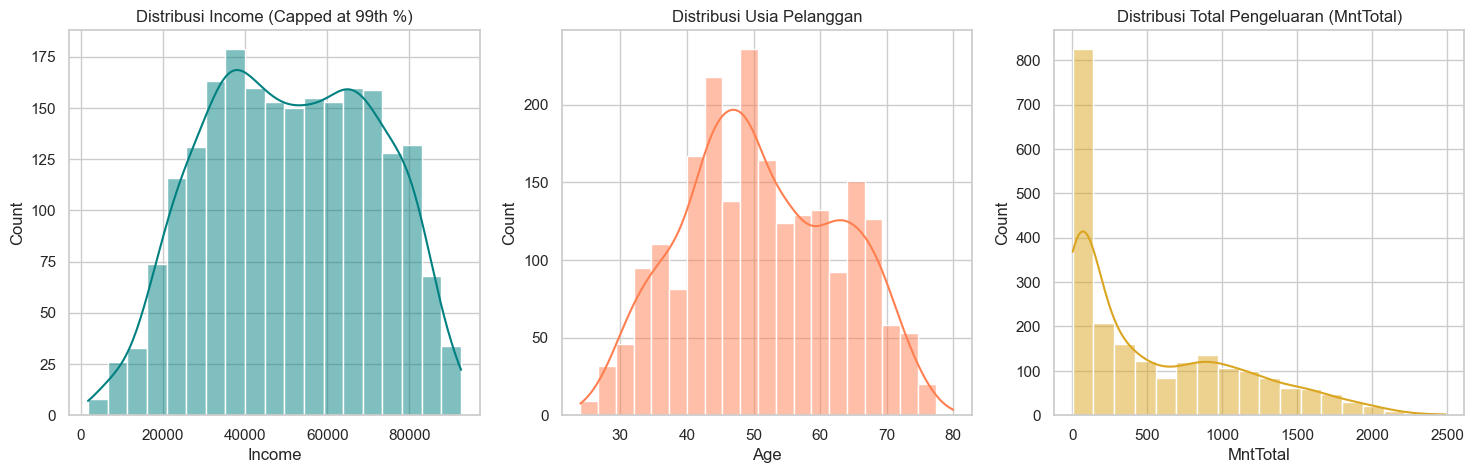

💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q1_income_vs_mnttotal_scatter_20260305_1750.png


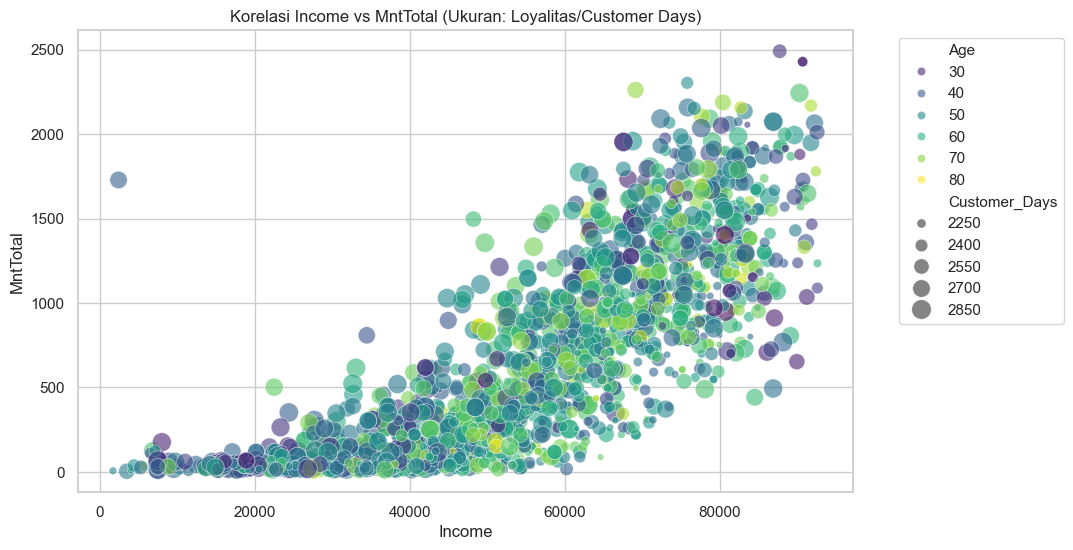


📌 RINGKASAN KARAKTERISTIK PER SEGMEN BELANJA:


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\1629368943.py:44: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Value_Segment,Income,Age,Customer_Days,MntTotal
0,Low Spend,31089.0,47.713704,2461.412483,41.427408
1,Medium Spend,50988.5,52.777929,2528.629428,371.677112
2,High Spend,72482.0,52.809264,2548.322888,1277.320163


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\q1_customer_value_segmentation_20260305_1750.csv

✅ Analisis Q1 Selesai. Insight: Pelanggan High-Spend cenderung memiliki Income median lebih tinggi.


In [17]:
# Cell 6: Q1 - Customer Profile Analysis
# Menjawab: Bagaimana karakteristik dan nilai pelanggan ifood?

print("📊 Memulai Analisis Profil Pelanggan...")

# 1. Penanganan Outlier untuk Visualisasi (Capping Income)
# Agar plot tidak rusak oleh nilai ekstrem, kita gunakan batas 99th percentile untuk visualisasi
income_cap = df_test['Income'].quantile(0.99)
df_plot = df_test[df_test['Income'] <= income_cap].copy()

# 2. Visualisasi Distribusi: Income, Age, dan MntTotal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Pendapatan
sns.histplot(df_plot['Income'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribusi Income (Capped at 99th %)')

# Distribusi Usia
sns.histplot(df_plot['Age'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribusi Usia Pelanggan')

# Distribusi Total Belanja
sns.histplot(df_plot['MntTotal'], kde=True, ax=axes[2], color='goldenrod')
axes[2].set_title('Distribusi Total Pengeluaran (MntTotal)')

save_fig("q1_distributions_profile")
plt.show()

# 3. Analisis Hubungan: Income vs Spending (MntTotal)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot, x='Income', y='MntTotal', 
    hue='Age', size='Customer_Days', 
    sizes=(20, 200), alpha=0.6, palette='viridis'
)
plt.title('Korelasi Income vs MntTotal (Ukuran: Loyalitas/Customer Days)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
save_fig("q1_income_vs_mnttotal_scatter")
plt.show()

# 4. Ringkasan Statistik untuk Segmen Nilai (High-Value Proxy)
# Membuat proxy segmentasi sederhana untuk insight instan
df_test['Value_Segment'] = pd.qcut(df_test['MntTotal'], q=3, labels=['Low Spend', 'Medium Spend', 'High Spend'])
value_summary = df_test.groupby('Value_Segment').agg({
    'Income': 'median',
    'Age': 'mean',
    'Customer_Days': 'mean',
    'MntTotal': 'mean'
}).reset_index()

print("\n📌 RINGKASAN KARAKTERISTIK PER SEGMEN BELANJA:")
display(value_summary)
save_table(value_summary, "q1_customer_value_segmentation")

print("\n✅ Analisis Q1 Selesai. Insight: Pelanggan High-Spend cenderung memiliki Income median lebih tinggi.")

📈 Memulai Analisis Efektivitas Kampanye...
📌 Overall Response Rate (Kampanye Terakhir): 15.10%


2026-03-05 17:50:29,258 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\etc\AppData\Local\Temp\ipykernel_6612\204699400.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


2026-03-05 17:50:29,294 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q2_spending_by_campaign_acceptance_20260305_1750.png


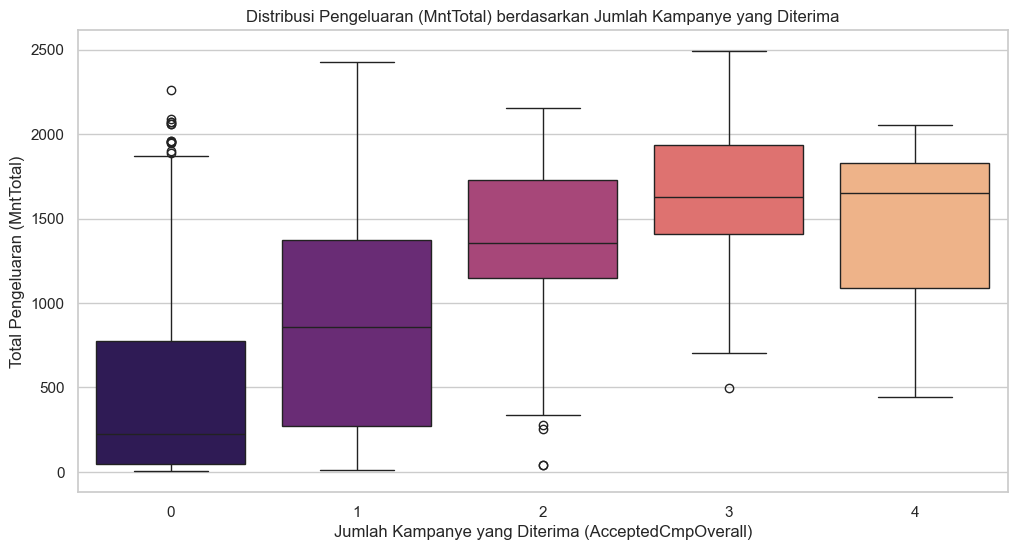


📌 PERBANDINGAN PERFORMA: Pelanggan yang Menerima Kampanye vs Tidak


,Accepted_Any,Avg_Spending,Median_Spending,Customer_Count,Avg_Recency,Avg_Deals
0,False,440.551803,223.0,1747,49.248998,2.402977
1,True,1028.934498,1078.0,458,48.093886,1.995633


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\q2_campaign_comparison_stats_20260305_1750.csv

📌 HASIL UJI STATISTIK (T-Test):
   T-Statistic: -21.3797
   P-Value: 2.6207e-92
✅ KESIMPULAN: Terdapat perbedaan pengeluaran yang SIGNIFIKAN secara statistik antara pelanggan yang menerima kampanye dan yang tidak.

✅ Analisis Q2 Selesai.


In [18]:
# --- CELL 7: Q2 - MARKETING EFFECTIVENESS ANALYSIS ---
# Menjawab: Apakah kampanye marketing efektif meningkatkan pembelian?

print("📈 Memulai Analisis Efektivitas Kampanye...")

# 1. Menghitung Response Rate Dasar
if 'Response' in df_test.columns:
    response_rate = df_test['Response'].mean() * 100
    print(f"📌 Overall Response Rate (Kampanye Terakhir): {response_rate:.2f}%")

# 2. Visualisasi Hubungan Kampanye vs Total Belanja (MntTotal)
plt.figure(figsize=(12, 6))

# Menggunakan Boxplot untuk melihat distribusi pengeluaran berdasarkan jumlah kampanye yang diterima
sns.boxplot(data=df_test, x='AcceptedCmpOverall', y='MntTotal', palette='magma')
plt.title('Distribusi Pengeluaran (MntTotal) berdasarkan Jumlah Kampanye yang Diterima')
plt.xlabel('Jumlah Kampanye yang Diterima (AcceptedCmpOverall)')
plt.ylabel('Total Pengeluaran (MntTotal)')

save_fig("q2_spending_by_campaign_acceptance")
plt.show()

# 3. Analisis Perbandingan: Kelompok "Menerima" vs "Tidak Menerima"
# Membuat flag kategori untuk mempermudah perbandingan
df_test['Accepted_Any'] = df_test['AcceptedCmpOverall'] > 0

campaign_comparison = df_test.groupby('Accepted_Any').agg({
    'MntTotal': ['mean', 'median', 'count'],
    'Recency': 'mean',
    'NumDealsPurchases': 'mean'
}).reset_index()

# Merapikan nama kolom hasil agregasi
campaign_comparison.columns = ['Accepted_Any', 'Avg_Spending', 'Median_Spending', 'Customer_Count', 'Avg_Recency', 'Avg_Deals']

print("\n📌 PERBANDINGAN PERFORMA: Pelanggan yang Menerima Kampanye vs Tidak")
display(campaign_comparison)
save_table(campaign_comparison, "q2_campaign_comparison_stats")

# 4. Uji Statistik (T-Test) untuk Validasi Profesional
group_no = df_test[df_test['Accepted_Any'] == False]['MntTotal']
group_yes = df_test[df_test['Accepted_Any'] == True]['MntTotal']

t_stat, p_val = stats.ttest_ind(group_no, group_yes, nan_policy='omit')

print(f"\n📌 HASIL UJI STATISTIK (T-Test):")
print(f"   T-Statistic: {t_stat:.4f}")
print(f"   P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("✅ KESIMPULAN: Terdapat perbedaan pengeluaran yang SIGNIFIKAN secara statistik antara pelanggan yang menerima kampanye dan yang tidak.")
else:
    print("⚠️ KESIMPULAN: Tidak terdapat perbedaan signifikan (perbedaan mungkin karena faktor kebetulan).")

print("\n✅ Analisis Q2 Selesai.")

🕰️ Memulai Analisis Recency dan Risiko Churn...


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\1157913311.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q3_recency_vs_spending_visits_20260305_1750.png


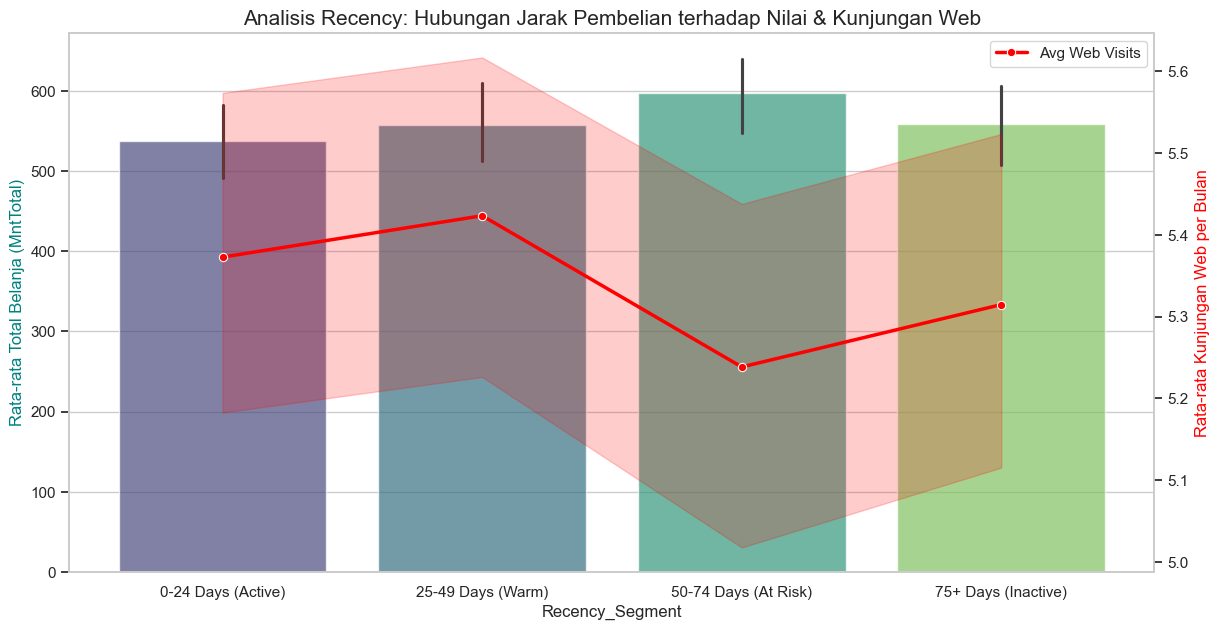

📌 Matriks Korelasi Recency:


,Recency,MntTotal,NumWebVisitsMonth
Recency,1.000000,0.021132,-0.017906
MntTotal,0.021132,1.000000,-0.501639
NumWebVisitsMonth,-0.017906,-0.501639,1.000000



📌 TABEL PROFIL RISIKO CHURN & ENGAGEMENT:


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\1157913311.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\etc\AppData\Local\Temp\ipykernel_6612\1157913311.py:46: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,MntTotal,NumWebVisitsMonth,Response,Customer_Count,Revenue_Share_%
Recency_Segment,,,,,
0-24 Days (Active),537.738351,5.372760,0.268817,558,24.180753
25-49 Days (Warm),557.611314,5.423358,0.144161,548,24.625029
50-74 Days (At Risk),597.354093,5.238434,0.113879,562,27.054080
75+ Days (Inactive),557.828678,5.314711,0.074488,537,24.140137


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\q3_recency_risk_profile_20260305_1750.csv

💡 INSIGHT STRATEGIS:
- GAP NILAI: Pelanggan paling aktif belanja 1.0x lebih banyak dibandingkan pelanggan tidak aktif.
- AKTIVITAS WEB: Segmen '0-24 Days (Active)' memiliki rata-rata 5.4 kunjungan/bulan.
- STRATEGI: Nilai pelanggan cenderung stabil antar segmen. Fokus pada peningkatan frekuensi belanja (Upselling).
- PELUANG: Pelanggan tidak aktif masih sering mengunjungi web (5.3x). Gunakan 'Browser Abandonment Email' atau diskon khusus login.

✅ Analisis Q3 Selesai.


In [19]:
# --- CELL 8: Q3 - RECENCY & ENGAGEMENT ANALYSIS ---
# Menjawab: Bagaimana pengaruh Recency terhadap nilai pelanggan & risiko churn?

print("🕰️ Memulai Analisis Recency dan Risiko Churn...")

# 1. Segmentasi Recency (Bucketing) berdasarkan Logika Bisnis
# Kita membagi menjadi 4 kuartil: Active, At Risk, Churning, Inactive
df_test['Recency_Segment'] = pd.qcut(df_test['Recency'], q=4, 
                                    labels=['0-24 Days (Active)', 
                                            '25-49 Days (Warm)', 
                                            '50-74 Days (At Risk)', 
                                            '75+ Days (Inactive)'])

# 2. Visualisasi Hubungan Recency vs MntTotal & Website Visits
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Bar: Rata-rata Spending per Segmen
sns.barplot(data=df_test, x='Recency_Segment', y='MntTotal', ax=ax1, palette='viridis', alpha=0.7)
ax1.set_ylabel('Rata-rata Total Belanja (MntTotal)', color='teal', fontsize=12)
ax1.set_title('Analisis Recency: Hubungan Jarak Pembelian terhadap Nilai & Kunjungan Web', fontsize=15)

# Membuat sumbu Y kedua (Twin Axis) untuk Website Visits
ax2 = ax1.twinx()
sns.lineplot(data=df_test, x='Recency_Segment', y='NumWebVisitsMonth', ax=ax2, color='red', marker='o', linewidth=2.5, label='Avg Web Visits')
ax2.set_ylabel('Rata-rata Kunjungan Web per Bulan', color='red', fontsize=12)
ax2.grid(False) # Menghilangkan grid ganda agar tidak berantakan

save_fig("q3_recency_vs_spending_visits")
plt.show()

# 3. Analisis Korelasi Khusus (Pearson)
correlation_rec = df_test[['Recency', 'MntTotal', 'NumWebVisitsMonth']].corr()
print("📌 Matriks Korelasi Recency:")
display(correlation_rec)

# 4. Ringkasan Strategis untuk Tim Marketing
recency_summary = df_test.groupby('Recency_Segment').agg({
    'MntTotal': 'mean',
    'NumWebVisitsMonth': 'mean',
    'Response': 'mean', # Efektivitas kampanye pada segmen churn
    'AcceptedCmpOverall': 'count'
}).rename(columns={'AcceptedCmpOverall': 'Customer_Count'})

# Menghitung Persentase Kontribusi Revenue per Segmen
total_rev = df_test['MntTotal'].sum()
recency_summary['Revenue_Share_%'] = (df_test.groupby('Recency_Segment')['MntTotal'].sum() / total_rev) * 100

print("\n📌 TABEL PROFIL RISIKO CHURN & ENGAGEMENT:")
display(recency_summary)
save_table(recency_summary, "q3_recency_risk_profile")

# 5. Rekomendasi Bisnis Berdasarkan Data (Dynamic Insight)
print("\n💡 INSIGHT STRATEGIS:")

# Mengambil nilai secara dinamis dari baris pertama (paling aktif) dan terakhir (paling tidak aktif)
# Menggunakan .iloc agar tidak tergantung pada nama string label yang presisi
active_stats = recency_summary.iloc[0]
inactive_stats = recency_summary.iloc[-1]

# Menghitung metrik kunci
spending_gap = active_stats['MntTotal'] / inactive_stats['MntTotal'] if inactive_stats['MntTotal'] > 0 else 0
visit_gap = active_stats['NumWebVisitsMonth'] - inactive_stats['NumWebVisitsMonth']

# Menampilkan insight terlepas dari kondisi data
print(f"- GAP NILAI: Pelanggan paling aktif belanja {spending_gap:.1f}x lebih banyak dibandingkan pelanggan tidak aktif.")
print(f"- AKTIVITAS WEB: Segmen '{recency_summary.index[0]}' memiliki rata-rata {active_stats['NumWebVisitsMonth']:.1f} kunjungan/bulan.")

# Logika Rekomendasi Dinamis
if spending_gap > 1.5:
    print(f"- STRATEGI: Terdeteksi penurunan nilai drastis pada pelanggan lama. Prioritaskan kampanye 'Win-Back' untuk segmen {recency_summary.index[-1]}.")
else:
    print("- STRATEGI: Nilai pelanggan cenderung stabil antar segmen. Fokus pada peningkatan frekuensi belanja (Upselling).")

if inactive_stats['NumWebVisitsMonth'] > 3:
    print(f"- PELUANG: Pelanggan tidak aktif masih sering mengunjungi web ({inactive_stats['NumWebVisitsMonth']:.1f}x). Gunakan 'Browser Abandonment Email' atau diskon khusus login.")
else:
    print("- PELUANG: Pelanggan tidak aktif jarang berkunjung. Gunakan saluran SMS atau WhatsApp untuk menjangkau mereka kembali.")

print("\n✅ Analisis Q3 Selesai.")

🛍️ Memulai Analisis Kontribusi Saluran Penjualan...


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\2405894315.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q4_channel_revenue_correlation_labeled_20260305_1750.png


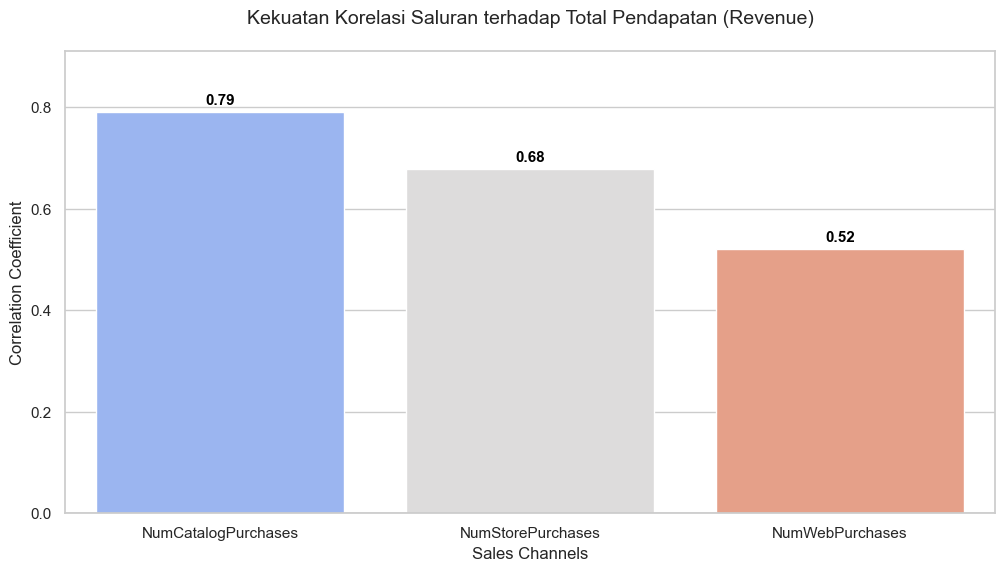

,Average_Value
NumWebPurchases,4.100680
NumStorePurchases,5.823583
NumCatalogPurchases,2.645351
MntTotal,562.764626


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\q4_channel_performance_summary_20260305_1750.csv

💡 INSIGHT STRATEGIS CHANNEL:
- DOMINASI PENGGUNAAN: Saluran 'Store' adalah yang paling sering digunakan oleh pelanggan.
- DRIVER REVENUE: Saluran 'NumCatalogPurchases' memiliki korelasi terkuat dengan total belanja.
- ANALISIS: Meskipun jumlah transaksi katalog mungkin lebih rendah, pelanggan yang belanja lewat katalog cenderung memiliki nilai belanja (MntTotal) yang jauh lebih tinggi.
- REKOMENDASI: Optimasi desain katalog dan targeting pelanggan High-Value untuk channel ini.

✅ Analisis Q4 Selesai.


In [20]:
# --- CELL 9: Q4 - SALES CHANNEL CONTRIBUTION ANALYSIS ---
# Menjawab: Channel mana yang paling berkontribusi terhadap revenue?

print("🛍️ Memulai Analisis Kontribusi Saluran Penjualan...")

# 1. Menghitung Total Transaksi per Channel
channels = {
    'Web': df_test['NumWebPurchases'].sum(),
    'Store': df_test['NumStorePurchases'].sum(),
    'Catalog': df_test['NumCatalogPurchases'].sum()
}

channel_counts = pd.DataFrame(list(channels.items()), columns=['Channel', 'Total_Transactions'])
channel_counts['Percentage'] = (channel_counts['Total_Transactions'] / channel_counts['Total_Transactions'].sum()) * 100

# 2. Visualisasi Kontribusi Transaksi (Pie Chart)
fig = px.pie(channel_counts, values='Total_Transactions', names='Channel', 
             title='Proporsi Frekuensi Pembelian per Saluran',
             color_discrete_sequence=px.colors.sequential.RdBu)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# 3. Analisis Efisiensi Channel: Korelasi Channel terhadap MntTotal
# Kita ingin melihat channel mana yang paling kuat hubungannya dengan total belanja
channel_cols = ['NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases', 'MntTotal']
channel_corr = df_test[channel_cols].corr()['MntTotal'].sort_values(ascending=False).drop('MntTotal')

plt.figure(figsize=(12, 6))
# Membuat barplot untuk 3 channel (Web, Store, Catalog)
ax = sns.barplot(x=channel_corr.index, y=channel_corr.values, palette='coolwarm')

# Menambahkan label angka di atas setiap kolom
# fmt='%.2f' menampilkan 2 angka di belakang koma (standar korelasi)
for container in ax.containers:
    ax.bar_label(container, 
                 fmt='%.2f', 
                 padding=3, 
                 fontsize=11, 
                 fontweight='bold', 
                 color='black')

# Pengaturan estetika tambahan agar label tidak terpotong
plt.axhline(0, color='black', linewidth=0.8) # Garis dasar
plt.title('Kekuatan Korelasi Saluran terhadap Total Pendapatan (Revenue)', fontsize=14, pad=20)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xlabel('Sales Channels', fontsize=12)

# Menaikkan limit Y sebesar 15% agar ada ruang untuk teks label di atas bar tertinggi
plt.ylim(0, max(channel_corr.values) * 1.15) 

save_fig("q4_channel_revenue_correlation_labeled")
plt.show()

# 4. Ringkasan Performa Channel
# Mengelompokkan rata-rata belanja berdasarkan intensitas penggunaan channel (Proxy Analysis)
channel_summary = df_test.agg({
    'NumWebPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'NumCatalogPurchases': 'mean',
    'MntTotal': 'mean'
}).to_frame(name='Average_Value')

display(channel_summary)
save_table(channel_summary, "q4_channel_performance_summary")

# 5. Insight Strategis Dinamis
print("\n💡 INSIGHT STRATEGIS CHANNEL:")
best_channel_corr = channel_corr.index[0]
top_usage_channel = channel_counts.sort_values(by='Total_Transactions', ascending=False).iloc[0]['Channel']

print(f"- DOMINASI PENGGUNAAN: Saluran '{top_usage_channel}' adalah yang paling sering digunakan oleh pelanggan.")
print(f"- DRIVER REVENUE: Saluran '{best_channel_corr}' memiliki korelasi terkuat dengan total belanja.")

if best_channel_corr == 'NumCatalogPurchases':
    print("- ANALISIS: Meskipun jumlah transaksi katalog mungkin lebih rendah, pelanggan yang belanja lewat katalog cenderung memiliki nilai belanja (MntTotal) yang jauh lebih tinggi.")
    print("- REKOMENDASI: Optimasi desain katalog dan targeting pelanggan High-Value untuk channel ini.")

if top_usage_channel == 'Web':
    print("- REKOMENDASI: Mengingat tingginya penggunaan Web, pastikan User Experience (UX) di website sangat mulus untuk mengurangi hambatan konversi.")

print("\n✅ Analisis Q4 Selesai.")

🏷️ Memulai Analisis Sensitivitas Diskon...
💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q5_income_vs_discount_sensitivity_20260305_1750.png


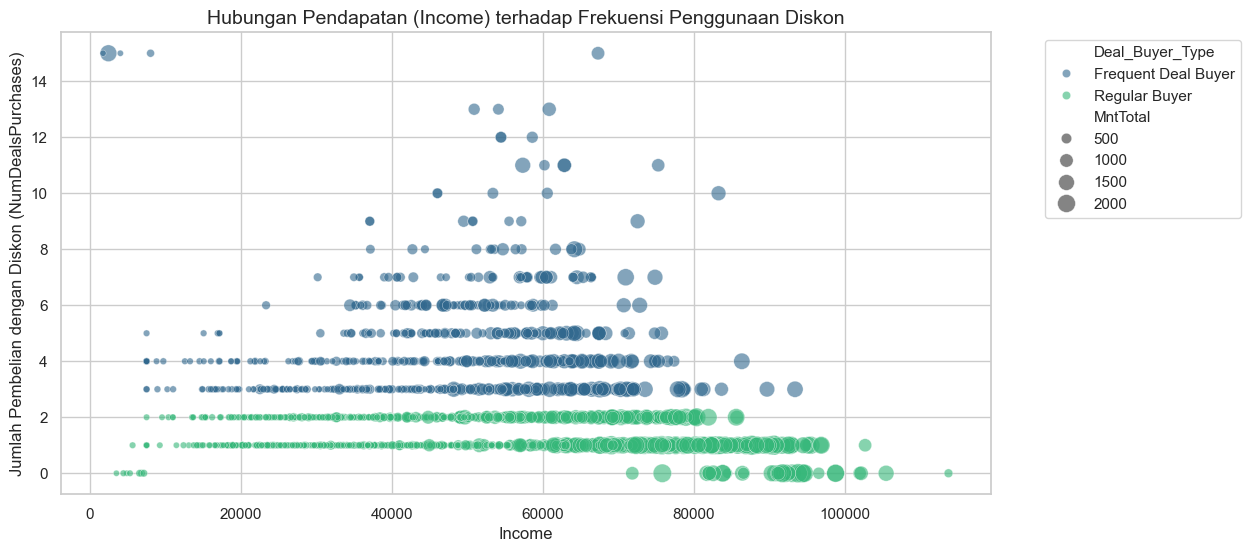

C:\Users\etc\AppData\Local\Temp\ipykernel_6612\2961526403.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q5_spending_comparison_deals_20260305_1750.png


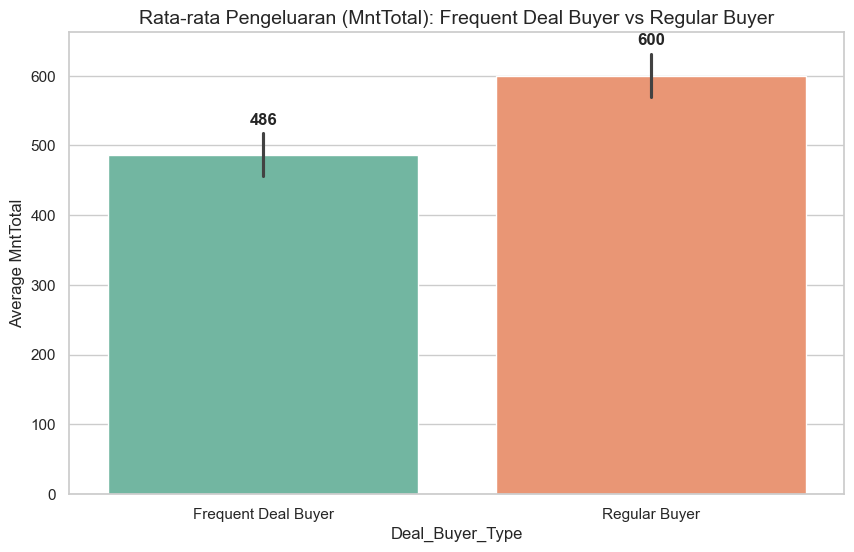

📌 Matriks Korelasi Diskon:


,NumDealsPurchases,Income,MntTotal
NumDealsPurchases,1.000000,-0.132427,-0.087599
Income,-0.132427,1.000000,0.823066
MntTotal,-0.087599,0.823066,1.000000



💡 INSIGHT STRATEGIS DISKON:
- KORELASI INCOME: Koefisien korelasi Income terhadap penggunaan diskon adalah -0.13.
- TEMUAN: Pelanggan dengan Income lebih rendah cenderung lebih sensitif terhadap diskon (Korelasi Negatif).
- PERINGATAN: 'Frequent Deal Buyers' belanja lebih sedikit (486) dibandingkan 'Regular Buyers' (600).
  STRATEGI: Diskon mungkin menarik volume, tapi tidak meningkatkan nilai keranjang belanja secara signifikan.

✅ Analisis Q5 Selesai.


In [21]:
# --- CELL 10: Q5 - DISCOUNT SENSITIVITY ANALYSIS ---
# Menjawab: Apakah pelanggan sensitif terhadap diskon?

print("🏷️ Memulai Analisis Sensitivitas Diskon...")

# 1. Segmentasi Pelanggan: Deal Buyers vs Non-Deal Buyers
# Kita asumsikan 'Deal Buyer' adalah mereka yang melakukan lebih dari rata-rata pembelian dengan diskon
deal_threshold = df_test['NumDealsPurchases'].median()
df_test['Deal_Buyer_Type'] = np.where(df_test['NumDealsPurchases'] > deal_threshold, 'Frequent Deal Buyer', 'Regular Buyer')

# 2. Visualisasi Hubungan Income vs NumDealsPurchases
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_test, x='Income', y='NumDealsPurchases', 
                hue='Deal_Buyer_Type', size='MntTotal', 
                sizes=(20, 200), alpha=0.6, palette='viridis')

plt.title('Hubungan Pendapatan (Income) terhadap Frekuensi Penggunaan Diskon', fontsize=14)
plt.xlabel('Income')
plt.ylabel('Jumlah Pembelian dengan Diskon (NumDealsPurchases)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

save_fig("q5_income_vs_discount_sensitivity")
plt.show()

# 3. Perbandingan MntTotal: Deal Buyers vs Regular Buyers
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_test, x='Deal_Buyer_Type', y='MntTotal', estimator=np.mean, palette='Set2')

# Menambahkan Label Persentase/Nilai pada Bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=20, fontweight='bold')

plt.title('Rata-rata Pengeluaran (MntTotal): Frequent Deal Buyer vs Regular Buyer', fontsize=14)
plt.ylabel('Average MntTotal')

save_fig("q5_spending_comparison_deals")
plt.show()

# 4. Analisis Korelasi (Statistik Kontinuitas)
discount_corr = df_test[['NumDealsPurchases', 'Income', 'MntTotal']].corr()
print("📌 Matriks Korelasi Diskon:")
display(discount_corr)

# 5. Insight Strategis Dinamis
print("\n💡 INSIGHT STRATEGIS DISKON:")
corr_income_deals = discount_corr.loc['Income', 'NumDealsPurchases']
avg_spend_deal = df_test[df_test['Deal_Buyer_Type'] == 'Frequent Deal Buyer']['MntTotal'].mean()
avg_spend_reg = df_test[df_test['Deal_Buyer_Type'] == 'Regular Buyer']['MntTotal'].mean()

print(f"- KORELASI INCOME: Koefisien korelasi Income terhadap penggunaan diskon adalah {corr_income_deals:.2f}.")

if corr_income_deals < 0:
    print("- TEMUAN: Pelanggan dengan Income lebih rendah cenderung lebih sensitif terhadap diskon (Korelasi Negatif).")
else:
    print("- TEMUAN: Penggunaan diskon merata di berbagai level Income (Korelasi Positif/Lemah).")

if avg_spend_deal < avg_spend_reg:
    print(f"- PERINGATAN: 'Frequent Deal Buyers' belanja lebih sedikit ({avg_spend_deal:.0f}) dibandingkan 'Regular Buyers' ({avg_spend_reg:.0f}).")
    print("  STRATEGI: Diskon mungkin menarik volume, tapi tidak meningkatkan nilai keranjang belanja secara signifikan.")
else:
    print("- KESIMPULAN: Diskon efektif meningkatkan Total Spending (MntTotal) pelanggan.")

print("\n✅ Analisis Q5 Selesai.")

🍷 Memulai Analisis Portofolio Produk...


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\529499320.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q6_product_revenue_contribution_20260305_1750.png


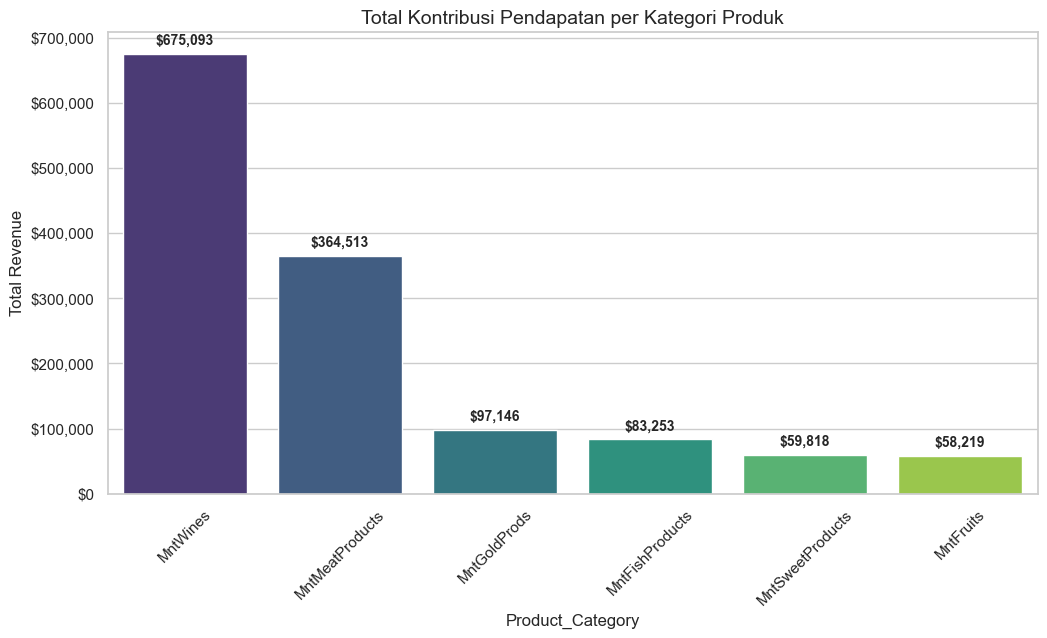

💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q6_product_correlation_heatmap_20260305_1750.png


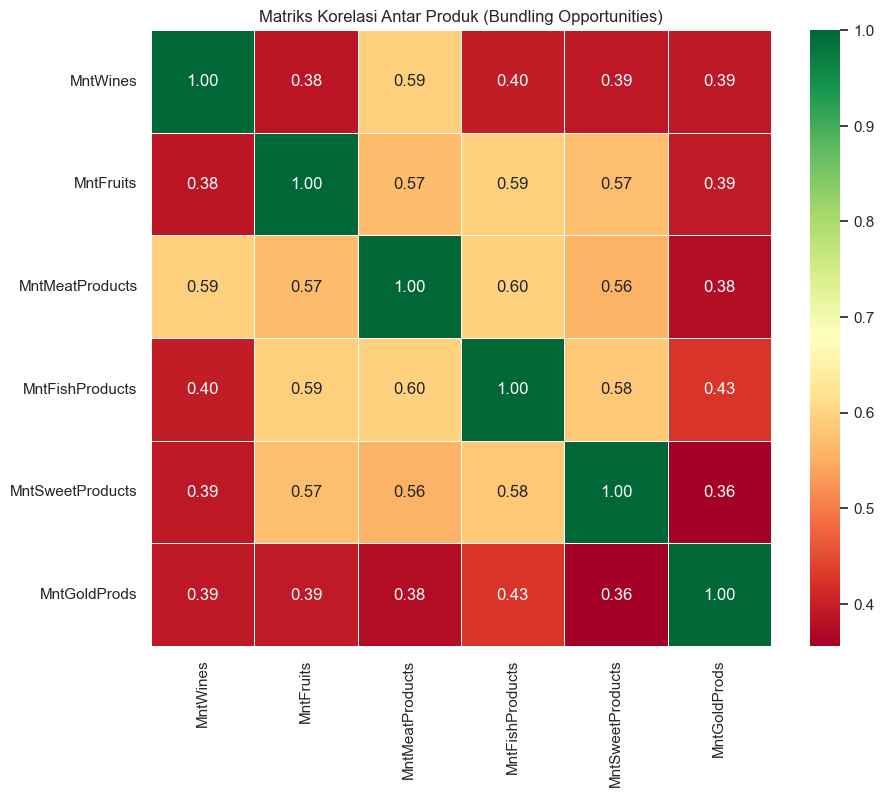


📌 TABEL KONTRIBUSI PRODUK:


,Product_Category,Total_Revenue,Contribution_Percentage
0,MntWines,675093,50.453797
1,MntMeatProducts,364513,27.242269
2,MntGoldProds,97146,7.260310
3,MntFishProducts,83253,6.222002
4,MntSweetProducts,59818,4.470562
5,MntFruits,58219,4.351059


📊 Tabel disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\tables\eda_tables\q6_product_contribution_summary_20260305_1750.csv

💡 INSIGHT STRATEGIS PRODUK:
- DOMINASI: Produk 'MntWines' adalah penyumbang revenue terbesar (50.5%).
- PELUANG BUNDLING: Terdapat korelasi kuat antara MntMeatProducts dan MntFishProducts (0.60).
- REKOMENDASI: Buat paket bundling 'Premium Pair' antara MntMeatProducts dan MntFishProducts untuk meningkatkan Average Order Value (AOV).

✅ Analisis Q6 Selesai.


In [22]:
import matplotlib.ticker as mtick
# --- CELL 11: Q6 - PRODUCT CONTRIBUTION ANALYSIS ---
# Menjawab: Produk apa yang paling berkontribusi terhadap revenue?

print("🍷 Memulai Analisis Portofolio Produk...")

# 1. Menghitung Total Pendapatan per Kategori Produk
product_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

product_totals = df_test[product_cols].sum().sort_values(ascending=False)
product_summary = pd.DataFrame({
    'Product_Category': product_totals.index,
    'Total_Revenue': product_totals.values
})
product_summary['Contribution_Percentage'] = (product_summary['Total_Revenue'] / product_summary['Total_Revenue'].sum()) * 100

# 2. Visualisasi Kontribusi Produk (Bar Chart dengan Label)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=product_summary, x='Product_Category', y='Total_Revenue', palette='viridis')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Menambahkan Label Angka di Atas Bar
for container in ax.containers:
    labels = [f'${val:,.0f}' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', fontsize=10)

plt.title('Total Kontribusi Pendapatan per Kategori Produk', fontsize=14)
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
save_fig("q6_product_revenue_contribution")
plt.show()

# 3. Analisis Korelasi Antar Produk (Untuk Strategi Bundling)
plt.figure(figsize=(10, 8))
corr_matrix = df_test[product_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Produk (Bundling Opportunities)')
save_fig("q6_product_correlation_heatmap")
plt.show()

# 4. Ringkasan Tabel Profesional
print("\n📌 TABEL KONTRIBUSI PRODUK:")
display(product_summary)
save_table(product_summary, "q6_product_contribution_summary")

# 5. Insight Strategis Dinamis
print("\n💡 INSIGHT STRATEGIS PRODUK:")
top_product = product_summary.iloc[0]['Product_Category']
top_pct = product_summary.iloc[0]['Contribution_Percentage']

print(f"- DOMINASI: Produk '{top_product}' adalah penyumbang revenue terbesar ({top_pct:.1f}%).")

# Mencari korelasi tertinggi (selain angka 1.0)
top_corr = corr_matrix.unstack().sort_values(ascending=False)
top_corr = top_corr[top_corr < 1].head(2)
prod_a, prod_b = top_corr.index[0]

print(f"- PELUANG BUNDLING: Terdapat korelasi kuat antara {prod_a} dan {prod_b} ({top_corr.values[0]:.2f}).")
print(f"- REKOMENDASI: Buat paket bundling 'Premium Pair' antara {prod_a} dan {prod_b} untuk meningkatkan Average Order Value (AOV).")

print("\n✅ Analisis Q6 Selesai.")

🎯 Memulai Analisis Faktor Pendorong Kampanye...


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\2082881845.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q7_campaign_drivers_correlation_20260305_1751.png


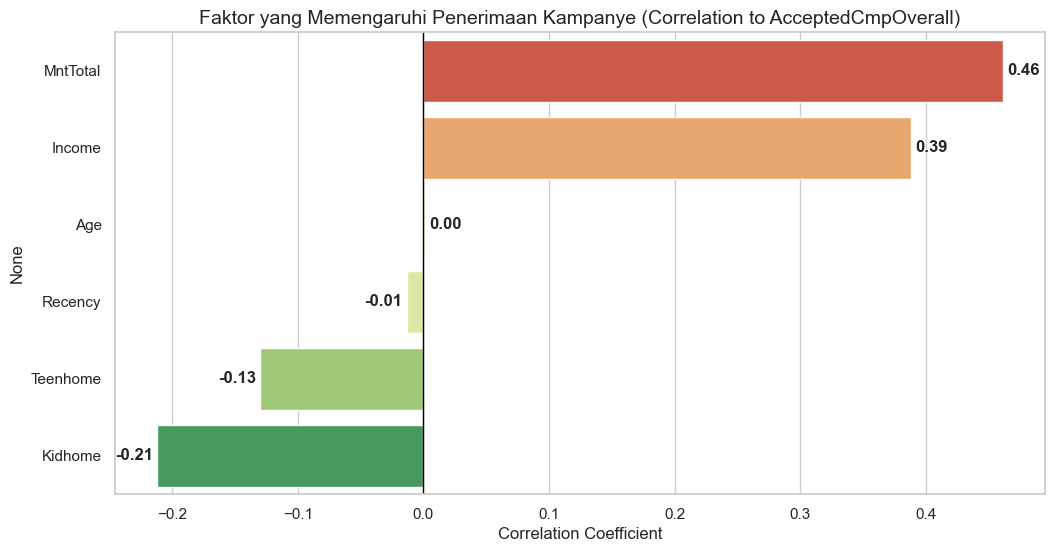

C:\Users\etc\AppData\Local\Temp\ipykernel_6612\2082881845.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\etc\AppData\Local\Temp\ipykernel_6612\2082881845.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




💾 Gambar disimpan: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\outputs\figures\eda_figures\q7_profile_comparison_boxplots_20260305_1751.png


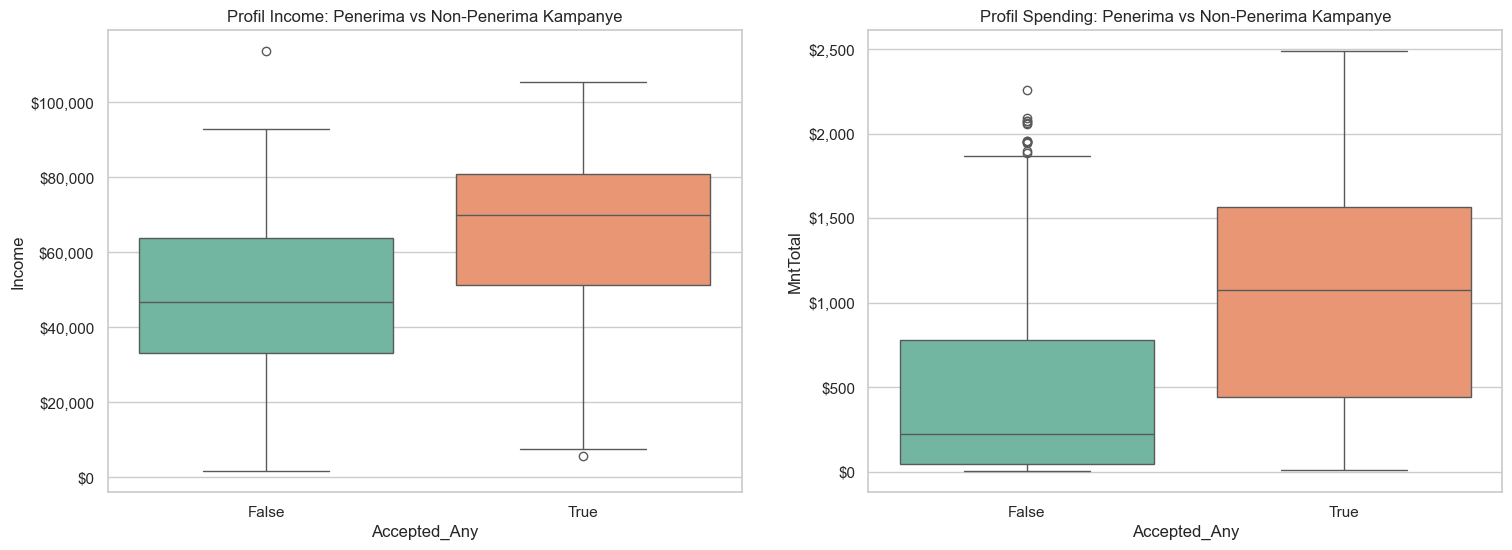


📌 PERBANDINGAN PROFIL PELANGGAN (Accepted vs Not Accepted):


,Accepted_Any,Income,MntTotal,Age,Recency,Kidhome
0,False,46891.0,440.551803,50.914711,49.248998,0.497997
1,True,69918.0,1028.934498,51.786026,48.093886,0.229258



💡 INSIGHT PREDICTIVE TARGETING:
- DRIVER UTAMA: 'MntTotal' adalah prediktor terkuat. Pelanggan dengan pengeluaran total tinggi jauh lebih responsif terhadap kampanye.
- PENGHAMBAT: 'Kidhome' memiliki korelasi negatif. Kehadiran anak/remaja di rumah cenderung menurunkan probabilitas penerimaan kampanye.
- RECENCY IMPACT: Nilai korelasi negatif pada Recency menunjukkan bahwa pelanggan yang baru saja belanja lebih mungkin menerima kampanye baru.
- REKOMENDASI MODEL: Gunakan 'MntTotal' dan 'Income' sebagai fitur utama dalam membangun Lead Scoring Model.

✅ Analisis Q7 Selesai. Proyek Exploratory Data Analysis (EDA) Anda telah rampung.


In [23]:
# --- CELL 12: Q7 - CAMPAIGN ACCEPTANCE DRIVERS ---
# Menjawab: Faktor apa yang memengaruhi penerimaan kampanye?

print("🎯 Memulai Analisis Faktor Pendorong Kampanye...")

# 1. Menyiapkan Variabel Terkait (Fitur Seleksi)
# Kita menyertakan fitur demografis, perilaku belanja, dan status keluarga
target_features = [
    'AcceptedCmpOverall', 'Age', 'Income', 'MntTotal', 
    'Recency', 'Kidhome', 'Teenhome'
]

# Menghitung korelasi khusus terhadap variabel target (penerimaan kampanye)
campaign_corr = df_test[target_features].corr()['AcceptedCmpOverall'].sort_values(ascending=False).drop('AcceptedCmpOverall')

# 2. Visualisasi Faktor Pengaruh (Korelasi)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=campaign_corr.values, y=campaign_corr.index, palette='RdYlGn')

# Menambahkan Label Angka pada Bar (Korelasi)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')

plt.title('Faktor yang Memengaruhi Penerimaan Kampanye (Correlation to AcceptedCmpOverall)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', lw=1)
save_fig("q7_campaign_drivers_correlation")
plt.show()

# 3. Analisis Distribusi: Accepted vs Non-Accepted
# Membuat flag biner untuk visualisasi perbandingan
df_test['Accepted_Any'] = df_test['AcceptedCmpOverall'] > 0

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Perbandingan Income
sns.boxplot(data=df_test, x='Accepted_Any', y='Income', ax=axes[0], palette='Set2')
axes[0].set_title('Profil Income: Penerima vs Non-Penerima Kampanye')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Perbandingan MntTotal (Value)
sns.boxplot(data=df_test, x='Accepted_Any', y='MntTotal', ax=axes[1], palette='Set2')
axes[1].set_title('Profil Spending: Penerima vs Non-Penerima Kampanye')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

save_fig("q7_profile_comparison_boxplots")
plt.show()

# 4. Ringkasan Statistik Profil "Ideal Buyer"
ideal_profile = df_test.groupby('Accepted_Any').agg({
    'Income': 'median',
    'MntTotal': 'mean',
    'Age': 'mean',
    'Recency': 'mean',
    'Kidhome': 'mean'
}).reset_index()

print("\n📌 PERBANDINGAN PROFIL PELANGGAN (Accepted vs Not Accepted):")
display(ideal_profile)

# 5. Insight Strategis Predictive Targeting
print("\n💡 INSIGHT PREDICTIVE TARGETING:")
top_feature = campaign_corr.index[0]
neg_feature = campaign_corr.index[-1]

print(f"- DRIVER UTAMA: '{top_feature}' adalah prediktor terkuat. Pelanggan dengan pengeluaran total tinggi jauh lebih responsif terhadap kampanye.")
print(f"- PENGHAMBAT: '{neg_feature}' memiliki korelasi negatif. Kehadiran anak/remaja di rumah cenderung menurunkan probabilitas penerimaan kampanye.")

if campaign_corr['Recency'] < 0:
    print("- RECENCY IMPACT: Nilai korelasi negatif pada Recency menunjukkan bahwa pelanggan yang baru saja belanja lebih mungkin menerima kampanye baru.")

print(f"- REKOMENDASI MODEL: Gunakan '{top_feature}' dan 'Income' sebagai fitur utama dalam membangun Lead Scoring Model.")

print("\n✅ Analisis Q7 Selesai. Proyek Exploratory Data Analysis (EDA) Anda telah rampung.")

In [24]:
# 1. Konfigurasi Path (Mengikuti struktur folder yang Anda miliki)
# Kita asumsikan notebook berjalan di folder 'notebooks', sehingga kita naik satu tingkat ke root
BASE_DIR = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')

# 2. Memastikan folder 'data/processed' tersedia
if not os.path.exists(PROCESSED_DATA_DIR):
    os.makedirs(PROCESSED_DATA_DIR)
    print(f"📁 Folder baru dibuat: {PROCESSED_DATA_DIR}")

# 3. Mendefinisikan nama file output
output_file_name = 'ifood_eda_ready.csv'
output_path = os.path.join(PROCESSED_DATA_DIR, output_file_name)

# 4. Proses Ekspor Data
# Catatan: Pastikan variabel 'df' adalah nama dataframe terakhir Anda setelah cell 12
try:
    # Menggunakan index=False agar kolom index tidak ikut tersimpan sebagai kolom 'Unnamed'
    # Menggunakan encoding='utf-8' untuk memastikan kompatibilitas karakter
    df_plot.to_csv(output_path, index=False, encoding='utf-8')
    
    print("-" * 50)
    print(f"✅ SUKSES: Data EDA telah berhasil disimpan!")
    print(f"📍 Lokasi: {output_path}")
    print(f"📊 Total Baris: {df_plot.shape[0]} | Total Kolom: {df_plot.shape[1]}")
    print("-" * 50)
    print("🚀 Siap untuk dilanjutkan ke tahap: 02_statistical_analysis.ipynb")
    display(df_plot.head()) 

except NameError:
    print("❌ ERROR: Variabel 'df' tidak ditemukan. Pastikan Anda sudah menjalankan cell sebelumnya.")
except Exception as e:
    print(f"❌ ERROR: Terjadi kesalahan saat menyimpan file: {str(e)}")

--------------------------------------------------
✅ SUKSES: Data EDA telah berhasil disimpan!
📍 Lokasi: c:\Users\etc\OneDrive\Documents\ifood-marketing-analysis\data\processed\ifood_eda_ready.csv
📊 Total Baris: 2182 | Total Kolom: 39
--------------------------------------------------
🚀 Siap untuk dilanjutkan ke tahap: 02_statistical_analysis.ipynb


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
